# Corporate Credit Rating — Classification Track
## Predicting Investment Grade vs. Non-Investment Grade (Binary Rating)

This notebook loads the preprocessed corporate financial dataset and builds, evaluates, visualizes, and compares classification models for credit risk classification.

## 1. Import Libraries

In [72]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,roc_curve
)

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Preprocessed Classification Dataset

Loading the preprocessed, encoded, and scaled training and test sets generated by `preprocessing.ipynb`.

In [73]:
data_dir = '../data' if os.path.exists('../data') else 'data'

train_df = pd.read_csv(os.path.join(data_dir, 'train_classification_preprocessed.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_classification_preprocessed.csv'))

# Features and Targets
X_train_c = train_df.drop(columns=['Binary Rating'])
y_train_c = train_df['Binary Rating']

X_test_c = test_df.drop(columns=['Binary Rating'])
y_test_c = test_df['Binary Rating']

# Scaled feature arrays for model fitting
X_train_c_scaled = X_train_c.values
X_test_c_scaled = X_test_c.values

print(f'Loaded preprocessed classification data from {data_dir}:')
print(f'Training set: X = {X_train_c.shape}, y = {y_train_c.shape}')
print(f'Testing set:  X = {X_test_c.shape}, y = {y_test_c.shape}')

Loaded preprocessed classification data from ../data:
Training set: X = (6244, 29), y = (6244,)
Testing set:  X = (1561, 29), y = (1561,)


## 20. Classification Part A - 5 Models

In [74]:
clf_models = {}
clf_results = []

def add_clf_result(name, model, preds, probs):
    clf_models[name] = model

    acc = accuracy_score(y_test_c, preds)
    precision = precision_score(y_test_c, preds, average='weighted', zero_division=0)
    recall = recall_score(y_test_c, preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test_c, preds, average='weighted')
    auc = roc_auc_score(y_test_c, probs)

    clf_results.append([
        name, acc, precision, recall, f1, auc
    ])

    print(name)
    print("Accuracy:", acc)
    print("Weighted Precision:", precision)
    print("Weighted Recall:", recall)
    print("Weighted F1:", f1)
    print("ROC-AUC:", auc)
    print()

    fpr, tpr, _ = roc_curve(y_test_c, probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")
    plt.plot([0, 1], [0, 1], '--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

### 20.1 Logistic Regression

Logistic Regression
Accuracy: 0.8007687379884689
Weighted Precision: 0.7972184121507274
Weighted Recall: 0.8007687379884689
Weighted F1: 0.7952119838881978
ROC-AUC: 0.8355016128447682



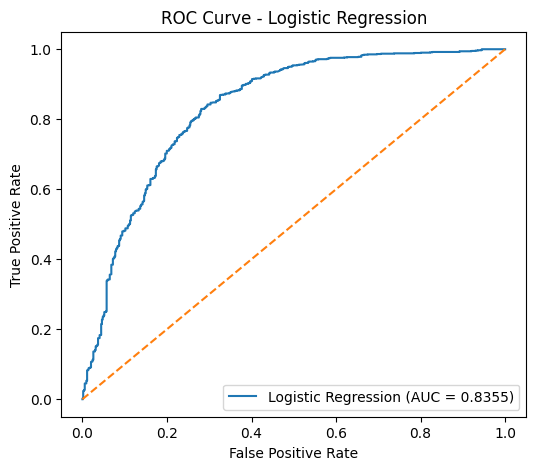

In [75]:
log_clf = LogisticRegression(random_state=42, max_iter=1000)
log_clf.fit(X_train_c_scaled, y_train_c)
log_preds = log_clf.predict(X_test_c_scaled)
log_probs = log_clf.predict_proba(X_test_c_scaled)[:, 1]
add_clf_result("Logistic Regression", log_clf, log_preds, log_probs)

### 20.2 K-Nearest Neighbors Classifier

Best K: 5
KNN Classifier
Accuracy: 0.866111467008328
Weighted Precision: 0.8650160271803884
Weighted Recall: 0.866111467008328
Weighted F1: 0.8639780794286734
ROC-AUC: 0.922442100685006



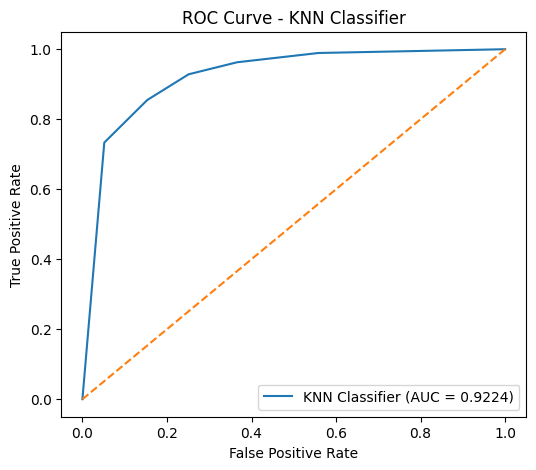

In [76]:
from sklearn.model_selection import cross_val_score

k_values = range(5,20)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_train_c_scaled, y_train_c, cv=5).mean()
    scores.append(score)

bestk = k_values[scores.index(max(scores))]
print("Best K:", bestk)

knn_clf = KNeighborsClassifier(n_neighbors=bestk)
knn_clf.fit(X_train_c_scaled, y_train_c)

knn_preds = knn_clf.predict(X_test_c_scaled)
knn_probs = knn_clf.predict_proba(X_test_c_scaled)[:, 1]

add_clf_result("KNN Classifier", knn_clf, knn_preds, knn_probs)

### 20.3 Gaussian Naive Bayes

Gaussian Naive Bayes
Accuracy: 0.7514413837283792
Weighted Precision: 0.754237604298015
Weighted Recall: 0.7514413837283792
Weighted F1: 0.7526587066682268
ROC-AUC: 0.806262005726505



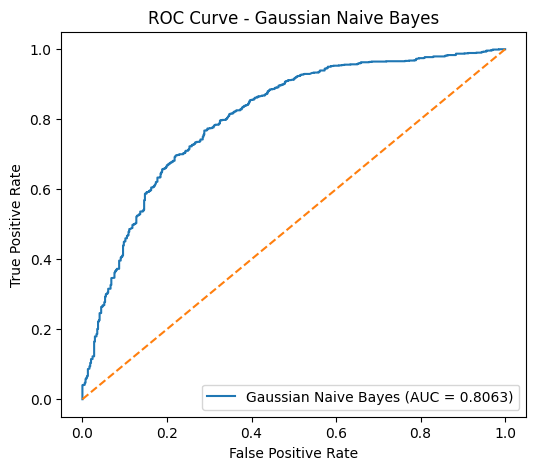

In [77]:
nb_clf = GaussianNB()
nb_clf.fit(X_train_c_scaled, y_train_c)
nb_preds = nb_clf.predict(X_test_c_scaled)
nb_probs = nb_clf.predict_proba(X_test_c_scaled)[:, 1]

add_clf_result("Gaussian Naive Bayes", nb_clf, nb_preds, nb_probs)

### 20.4 Decision Tree Classifier

Best Parameters: {'max_depth': None}
Decision Tree Classifier
Accuracy: 0.8923766816143498
Weighted Precision: 0.8927930303937515
Weighted Recall: 0.8923766816143498
Weighted F1: 0.8925597726457725
ROC-AUC: 0.895569207350223



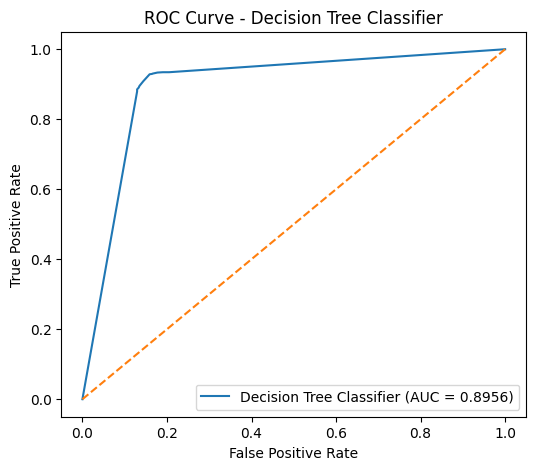

In [78]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7, 10, None]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

dt_grid.fit(X_train_c_scaled, y_train_c)

print("Best Parameters:", dt_grid.best_params_)

dtc_clf = dt_grid.best_estimator_

dtc_preds = dtc_clf.predict(X_test_c_scaled)
dtc_probs = dtc_clf.predict_proba(X_test_c_scaled)[:, 1]

add_clf_result("Decision Tree Classifier", dtc_clf, dtc_preds, dtc_probs)

### Decision Tree Visualisation

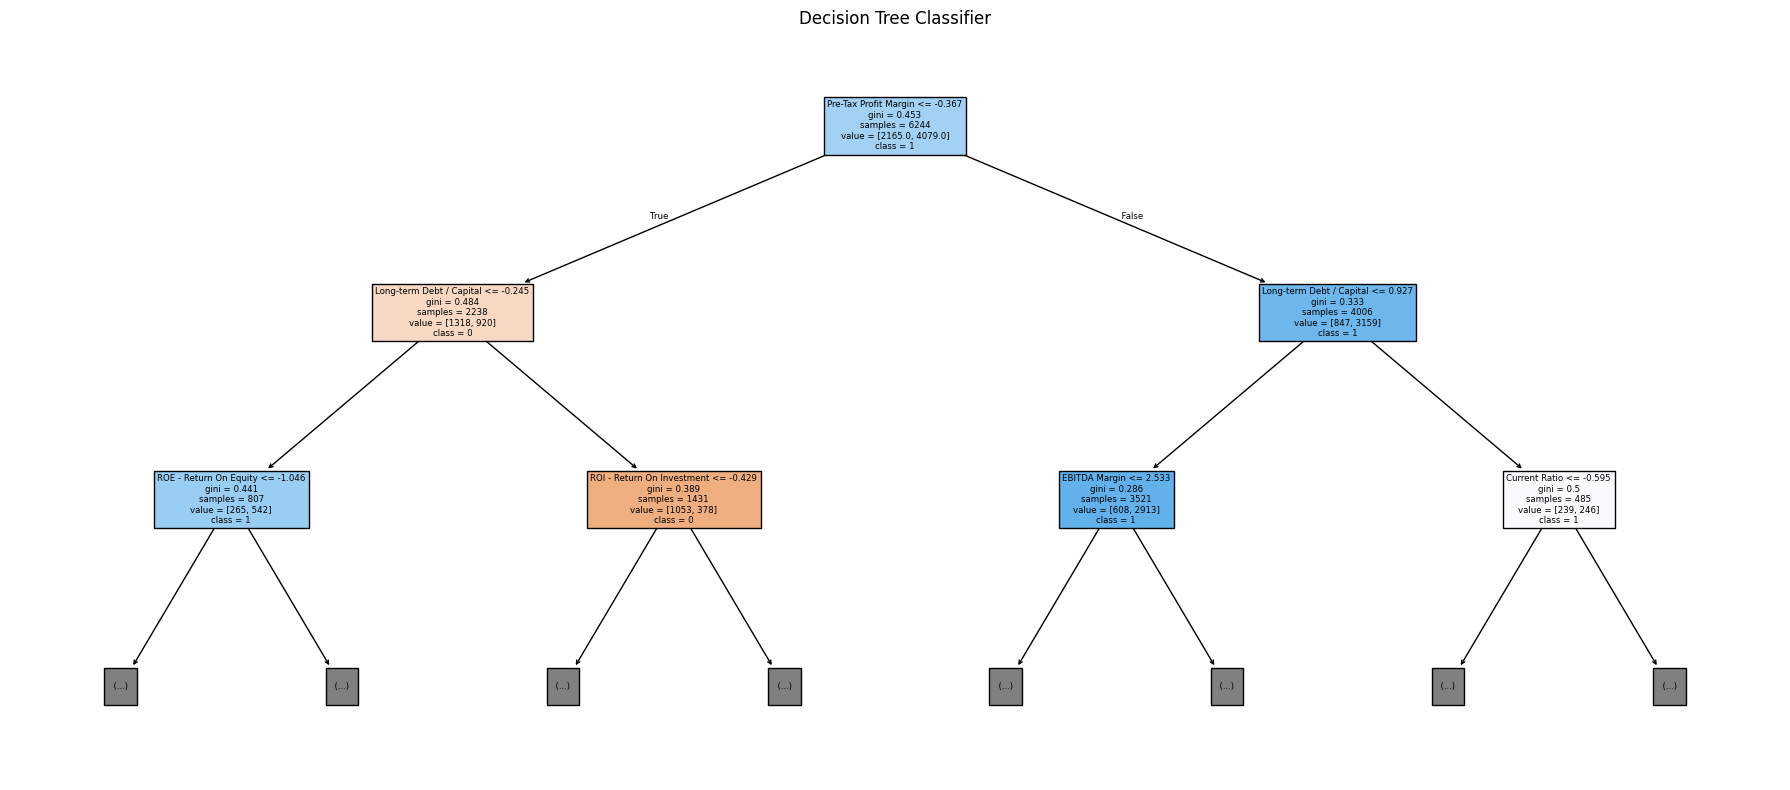

In [79]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 8))
plot_tree(
    dtc_clf,
    feature_names=X_train_c.columns,
    class_names=['0', '1'],
    filled=True,
    max_depth=2
)
plt.title('Decision Tree Classifier')
plt.tight_layout()
plt.show()

### 20.5 Support Vector Classifier

Best Parameters: {'C': 10, 'kernel': 'rbf'}
Support Vector Classifier
Accuracy: 0.8686739269698911
Weighted Precision: 0.8683118091324493
Weighted Recall: 0.8686739269698911
Weighted F1: 0.8659500947142684
ROC-AUC: 0.9169774564169475



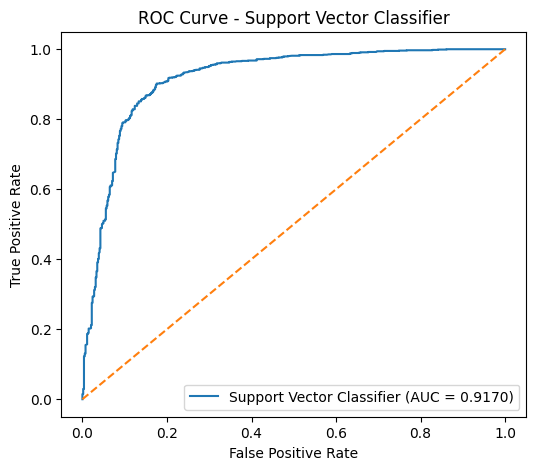

In [82]:
from sklearn.model_selection import GridSearchCV 
params = { 'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'] } 
svc_grid = GridSearchCV( SVC(random_state=42, probability=True), params, cv=5, scoring='accuracy' ) 
svc_grid.fit(X_train_c_scaled, y_train_c) 
print("Best Parameters:", svc_grid.best_params_) 
svc_clf = svc_grid.best_estimator_ 
svc_preds = svc_clf.predict(X_test_c_scaled) 
svc_probs = svc_clf.predict_proba(X_test_c_scaled)[:, 1] 
add_clf_result("Support Vector Classifier", svc_clf, svc_preds, svc_probs)


### Observation

The first levels of the tree show the main features used to separate the two rating classes. Deeper branches represent further decisions.


## 21. Classification Comparison

In [80]:
clf_results_df = pd.DataFrame(
    clf_results,
    columns=[
        'Model', 'Accuracy', 'Precision',
        'Recall', 'Weighted F1', 'ROC-AUC'
    ]
)

clf_results_df = clf_results_df.sort_values(
    by='Accuracy', ascending=False
).reset_index(drop=True)

clf_results_df

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
0,Decision Tree Classifier,0.892377,0.892793,0.892377,0.892560,0.895569
1,KNN Classifier,0.866111,0.865016,0.866111,0.863978,0.922442
2,Logistic Regression,0.800769,0.797218,0.800769,0.795212,0.835502
3,Gaussian Naive Bayes,0.751441,0.754238,0.751441,0.752659,0.806262


### Observation

The classification table compares the five Part-A algorithms. Accuracy shows overall correct predictions, while weighted F1 gives a better view when the classes are not perfectly balanced.

## 22. Confusion Matrices

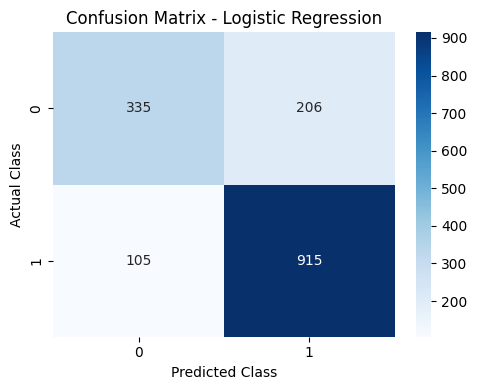

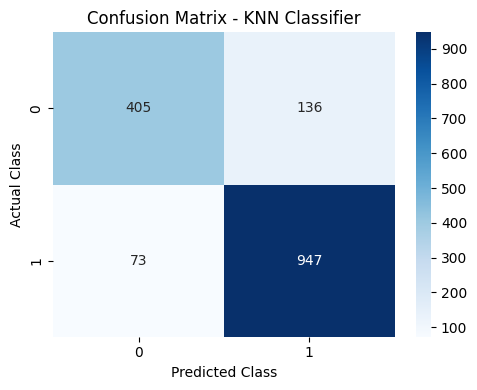

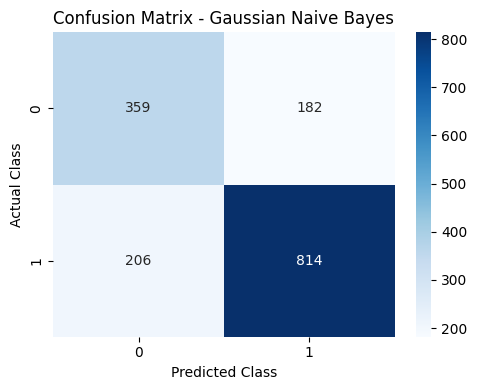

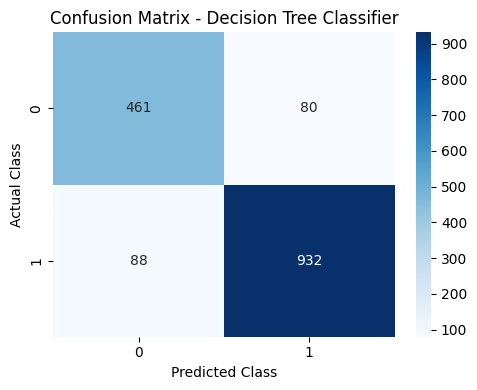

In [81]:
for name, model in clf_models.items():
    preds = model.predict(X_test_c_scaled)
    cm = confusion_matrix(y_test_c, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - ' + name)
    plt.xlabel('Predicted Class')
    plt.ylabel('Actual Class')
    plt.tight_layout()
    plt.show()

### Observation

The diagonal values in each confusion matrix are correct predictions. Off-diagonal values show the classification errors between the two binary classes.

## 23. Review 1 Conclusion

### Summary

- The dataset was audited and cleaned.
- Exploratory analysis was performed on the financial features.
- A meaningful average profit-margin feature was created.
- Categorical data was encoded and numerical features were scaled using training data.
- All **10 required regression algorithms** were implemented and compared.
- Hyperparameter tuning was applied to two regression models.
- 5-fold cross-validation was performed for the two best regression models.
- Required regression visualisations were added.
- All **5 Review 1 classification algorithms** were implemented and evaluated.

The best model should be selected from the comparison tables based on the required metrics and the trade-off between performance and model complexity.

## Note on AI Assistance

AI assistance was used for code scaffolding and notebook organization. The dataset-specific analysis, observations, feature engineering choice, and final interpretation is reviewed by us .